# Lab 03: LangGraph Human-in-the-Loop for Food Safety Decisions

Concept from the slides:
- AI can help detect signals, summarize evidence, and recommend next checks for a human reviewer.
- AI must not make final safety/compliance decisions by itself.
- Decisions such as release, hold, quarantine, recall, or closing a safety deviation require human approval.
- Every decision should leave an evidence log for auditability, including the checks the agent recommends back to the human.

Default provider: OpenAI API (`PROVIDER = "openai"`). Optional provider: Groq (`PROVIDER = "groq"`).


## Flow

Scenario: a cooked product batch has a cooling-time deviation.

This lab uses a simple 3-agent workflow. Each agent has a different job, while the final operational decision stays with a human when risk is medium or high.

```text
case input
  ↓
Agent 1: evidence_triage_agent
  ├─ missing/weak evidence → request_more_data → END
  ↓
Agent 2: risk_analysis_agent
  ↓
Agent 3: action_brief_agent
  ├─ LOW → MONITOR → auto_log_low_risk → END
  ├─ MEDIUM → INVESTIGATE → supervisor_review → finalize_log → END
  └─ HIGH → HOLD_FOR_QA_REVIEW → qa_review → finalize_log → END
```

Agent roles:
- `evidence_triage_agent`: checks whether the minimum evidence is complete and prepares a data request if not.
- `risk_analysis_agent`: classifies risk using a clear training rubric.
- `action_brief_agent`: converts the risk level into a workflow status, review role, action brief, recommended checks, and review questions.

Decision boundary:
- `MONITOR`: low risk, complete evidence, log and track only.
- `INVESTIGATE`: medium risk, send to supervisor/process owner for human review.
- `HOLD_FOR_QA_REVIEW`: high risk or safety-critical signal, send to QA/Food Safety review.
- AI agents prepare analysis and briefs; humans approve operational decisions.

## Setup

In [ ]:
# %%capture
# !pip install -qU langchain-openai

In [1]:
# if using groq api (Free Tier) => don't run the cell above, run this block instead
!pip install -qU langchain-groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 3.6 MB/s eta 0:00:00


In [2]:
from IPython.display import HTML, display, Image

def set_css():
  display(HTML('''
  <style>
    pre {
        white-space: pre-wrap;
    }
  </style>
  '''))
get_ipython().events.register('pre_run_cell', set_css)

In [3]:
%%capture
!pip -q install langchain-core langchain-community langgraph

In [4]:
import json
import getpass
import os
from typing import TypedDict, Literal, List, Dict, Any

from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command

In [6]:
PROVIDER = "groq"  # Change only this line : "openai" or "groq"

if PROVIDER == "openai":
    from langchain_openai import ChatOpenAI
    if "OPENAI_API_KEY" not in os.environ:
        os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")
    llm = ChatOpenAI(
        model="gpt-5-mini",
        temperature=0,
        max_retries=2,
    )
elif PROVIDER == "groq":
    from langchain_groq import ChatGroq
    if "GROQ_API_KEY" not in os.environ:
        os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq API key: ")
    llm = ChatGroq(
        model="llama-3.1-8b-instant",
        temperature=0,
        max_tokens=None,
        timeout=None,
        max_retries=2,
    )
else:
    raise ValueError("PROVIDER must be 'openai' or 'groq'")

print(f"Using provider: {PROVIDER}")

Enter your Groq API key: ··········
Using provider: groq


## Define State

In [7]:
class FoodSafetyState(TypedDict, total=False):
    case_id: str
    product: str
    batch_id: str
    cooling_minutes_to_5c: int
    max_temperature_c: float
    lab_result_status: str
    batch_record_complete: bool
    sensor_record_complete: bool
    complaint_count_14d: int

    operator_note: str
    sensor_trend_note: str
    qa_note: str
    complaint_note: str

    evidence_complete: bool
    missing_evidence: List[str]
    data_request_message: str

    risk_level: str
    evidence_summary: List[str]
    reasoning: str

    ai_recommendation: str
    review_role: str
    action_brief: str
    recommended_checks: List[str]
    review_questions: List[str]

    human_decision: str
    human_comment: str
    final_status: str

In [8]:
# JUST HELPER FUNCTION FOR FORMATTING
def extract_json(text: str) -> dict:
    """Extract JSON from an LLM response, including responses wrapped in markdown fences."""
    cleaned = text.strip()
    if cleaned.startswith("```"):
        cleaned = cleaned.strip("`")
        cleaned = cleaned.replace("json", "", 1).strip()
    start = cleaned.find("{")
    end = cleaned.rfind("}")
    if start == -1 or end == -1:
        raise ValueError(f"No JSON object found in LLM response: {text}")
    return json.loads(cleaned[start:end + 1])


def case_payload_from_state(state: FoodSafetyState) -> Dict[str, Any]:
    return {
        "case_id": state["case_id"],
        "product": state["product"],
        "batch_id": state["batch_id"],
        "cooling_minutes_to_5c": state["cooling_minutes_to_5c"],
        "internal_cooling_limit_minutes": 120,
        "max_temperature_c": state["max_temperature_c"],
        "target_temperature_c": 5,
        "lab_result_status": state["lab_result_status"],
        "batch_record_complete": state["batch_record_complete"],
        "sensor_record_complete": state["sensor_record_complete"],
        "complaint_count_14d": state["complaint_count_14d"],
        "operator_note": state.get("operator_note", ""),
        "sensor_trend_note": state.get("sensor_trend_note", ""),
        "qa_note": state.get("qa_note", ""),
        "complaint_note": state.get("complaint_note", ""),
    }

## Define Node / Conditional Edge Function

In [9]:
# Node (LLM Node)
def evidence_triage_agent(state: FoodSafetyState):
    """Agent 1: Check whether evidence is complete before risk analysis."""
    system_prompt = """
You are Evidence Triage Agent for a high-value food processing plant.
Your job is to decide whether the minimum evidence is complete enough for risk analysis.
Do not classify food safety risk. Do not recommend monitor, investigate, hold, release, quarantine, or recall.

Minimum required evidence:
- batch_record_complete must be true
- sensor_record_complete must be true
- lab_result_status must be available and non-empty

Also inspect semi-structured notes such as operator_note, sensor_trend_note, qa_note, and complaint_note. If a note says a required attachment is only partial, corrupted, manually estimated, or cannot be linked to the batch/time window, treat that evidence as weak and request clarification.

Return only valid JSON with these keys:
- evidence_complete: true or false
- missing_evidence: array of missing evidence names
- data_request_message: one short message asking the responsible data owner for the missing evidence; use an empty string if evidence is complete
""".strip()

    response = llm.invoke([
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": "Triage this case and return JSON only:\n" + json.dumps(case_payload_from_state(state), indent=2)},
    ])
    parsed = extract_json(response.content)

    # Hard guardrail: do not rely only on the LLM for required-field checks.
    missing = list(parsed.get("missing_evidence", []))
    if not state["batch_record_complete"] and "batch_record" not in missing:
        missing.append("batch_record")
    if not state["sensor_record_complete"] and "sensor_record" not in missing:
        missing.append("sensor_record")
    if not state.get("lab_result_status") and "lab_result_status" not in missing:
        missing.append("lab_result_status")

    evidence_complete = len(missing) == 0
    data_request_message = parsed.get("data_request_message", "")
    if not evidence_complete and not data_request_message:
        data_request_message = "Please provide the missing evidence before risk analysis: " + ", ".join(missing)

    return {
        "evidence_complete": evidence_complete,
        "missing_evidence": missing,
        "data_request_message": data_request_message,
    }

# Conditional Edge Function
def route_after_evidence_triage(state: FoodSafetyState) -> Literal["missing_data", "analyze"]:
    if not state["evidence_complete"]:
        return "missing_data"
    return "analyze"

# Node (Logic Node)
def request_more_data(state: FoodSafetyState):
    return {"final_status": "WAITING_FOR_MORE_EVIDENCE"}


In [10]:
# Node (LLM Node)
def risk_analysis_agent(state: FoodSafetyState):
    """Agent 2: Classify risk using a clear rubric."""
    system_prompt = """
You are Risk Analysis Agent for a high-value food processing plant.
Analyze complete case evidence and classify risk.
Use both structured values and semi-structured notes. Interpret operator notes, sensor trend notes, QA notes, and complaint notes for context that simple thresholds may miss.
You may summarize evidence, but you must not make final release, hold, quarantine, recall, or close-deviation decisions.
Those decisions require human approval from a supervisor, QA, or Food Safety.

Return only valid JSON with these keys:
- risk_level: LOW, MEDIUM, or HIGH
- evidence_summary: array of short evidence bullets
- reasoning: one short paragraph

Use this internal training triage rubric. It is not a regulatory release rule; plant SOP, HACCP plan, and QA/Food Safety authority still govern final decisions.

LOW if all are true:
- batch record, sensor record, and lab result status are available
- lab_result_status is "pass"
- cooling_minutes_to_5c <= 105
- max_temperature_c <= 5
- complaint_count_14d == 0
- notes do not mention equipment alarms, manual data correction, sensor uncertainty, customer-impact themes, or unresolved QA concerns

MEDIUM if evidence is complete and lab_result_status is "pass", and at least one non-critical abnormal signal exists, such as:
- cooling_minutes_to_5c is 106-120
- max_temperature_c is > 5 and <= 7
- complaint_count_14d is 1-2 without a clear same-batch safety signal
- process data or notes suggest drift, equipment/shift issue, manual adjustment, partial customer-impact signal, or investigation need, but not an immediate QA hold

HIGH if any are true:
- lab_result_status is not "pass"
- cooling_minutes_to_5c > 120
- max_temperature_c > 7
- cooling_minutes_to_5c > 120 and max_temperature_c > 5 in the same case
- complaint_count_14d >= 3, especially when combined with process deviation
- structured data or notes suggest potential food safety, compliance, release/hold, quarantine, recall, or close-deviation impact
""".strip()

    response = llm.invoke([
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": "Analyze this complete-evidence case and return JSON only:\n" + json.dumps(case_payload_from_state(state), indent=2)},
    ])
    parsed = extract_json(response.content)

    return {
        "risk_level": parsed["risk_level"],
        "evidence_summary": parsed["evidence_summary"],
        "reasoning": parsed.get("reasoning", ""),
    }

In [11]:
def action_brief_agent(state: FoodSafetyState):
    """Agent 3: Convert risk into workflow status and prepare the human review brief."""
    system_prompt = """
You are Action Brief Agent for a high-value food processing plant.
Use the risk level, evidence summary, reasoning, and semi-structured notes to prepare the next workflow status and review brief.
The brief should translate messy plant-floor evidence into practical next steps for the right human owner.
It should also recommend the specific checks or evidence items the human should verify before making a decision.
Do not make final release, hold, quarantine, recall, or close-deviation decisions.

Deterministic mapping:
- LOW -> ai_recommendation = MONITOR, review_role = NOT_REQUIRED_LOW_RISK
- MEDIUM -> ai_recommendation = INVESTIGATE, review_role = SUPERVISOR_OR_PROCESS_OWNER
- HIGH -> ai_recommendation = HOLD_FOR_QA_REVIEW, review_role = QA_OR_FOOD_SAFETY

Return only valid JSON with these keys:
- ai_recommendation: MONITOR, INVESTIGATE, or HOLD_FOR_QA_REVIEW
- review_role: NOT_REQUIRED_LOW_RISK, SUPERVISOR_OR_PROCESS_OWNER, or QA_OR_FOOD_SAFETY
- action_brief: one concise paragraph for the reviewer or evidence log
- recommended_checks: array of 2-4 practical checks for the human to verify before deciding; [] for low-risk monitor-only cases
- review_questions: array of 2-4 practical questions for the reviewer; [] for low-risk monitor-only cases
""".strip()

    payload = {
        "case": case_payload_from_state(state),
        "risk_level": state["risk_level"],
        "evidence_summary": state["evidence_summary"],
        "reasoning": state["reasoning"],
    }
    response = llm.invoke([
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": "Prepare the action brief and return JSON only:\n" + json.dumps(payload, indent=2)},
    ])
    parsed = extract_json(response.content)

    # Hard guardrail: enforce the mapping even if the LLM response drifts.
    risk_level = state["risk_level"].upper()
    if risk_level == "LOW":
        ai_recommendation = "MONITOR"
        review_role = "NOT_REQUIRED_LOW_RISK"
    elif risk_level == "MEDIUM":
        ai_recommendation = "INVESTIGATE"
        review_role = "SUPERVISOR_OR_PROCESS_OWNER"
    elif risk_level == "HIGH":
        ai_recommendation = "HOLD_FOR_QA_REVIEW"
        review_role = "QA_OR_FOOD_SAFETY"
    else:
        raise ValueError(f"Unknown risk_level: {state['risk_level']}")

    return {
        "ai_recommendation": ai_recommendation,
        "review_role": review_role,
        "action_brief": parsed.get("action_brief", ""),
        "recommended_checks": parsed.get("recommended_checks", parsed.get("review_questions", [])),
        "review_questions": parsed.get("review_questions", []),
    }


def route_after_action_brief(state: FoodSafetyState) -> Literal["monitor", "supervisor", "qa"]:
    if state["ai_recommendation"] == "MONITOR":
        return "monitor"
    if state["ai_recommendation"] == "INVESTIGATE":
        return "supervisor"
    return "qa"

In [12]:
def auto_log_low_risk(state: FoodSafetyState):
    return {
        "final_status": "AUTO_LOGGED_MONITOR_ONLY",
        "human_decision": "NOT_REQUIRED_LOW_RISK",
    }

def supervisor_review(state: FoodSafetyState):
    """Pause for supervisor/process owner review on medium-risk investigate cases."""
    review_payload = {
        "message": "Supervisor/process owner review required for INVESTIGATE status.",
        "case_id": state["case_id"],
        "batch_id": state["batch_id"],
        "risk_level": state["risk_level"],
        "ai_recommendation": state["ai_recommendation"],
        "action_brief": state["action_brief"],
        "recommended_checks": state.get("recommended_checks", []),
        "review_questions": state["review_questions"],
        "approval_options": [
            "CONTINUE_INVESTIGATION",
            "ESCALATE_TO_QA",
            "REQUEST_MORE_EVIDENCE",
            "CLOSE_AS_MONITOR_ONLY",
        ],
    }
    human_input = interrupt(review_payload)
    return {
        "human_decision": human_input["decision"],
        "human_comment": human_input.get("comment", ""),
    }


def qa_review(state: FoodSafetyState):
    """Pause for QA/Food Safety review on high-risk cases."""
    review_payload = {
        "message": "QA/Food Safety approval required for HOLD_FOR_QA_REVIEW status.",
        "case_id": state["case_id"],
        "batch_id": state["batch_id"],
        "risk_level": state["risk_level"],
        "ai_recommendation": state["ai_recommendation"],
        "action_brief": state["action_brief"],
        "recommended_checks": state.get("recommended_checks", []),
        "review_questions": state["review_questions"],
        "approval_options": [
            "HOLD_FOR_QA_REVIEW",
            "QUARANTINE",
            "RELEASE_WITH_JUSTIFICATION",
            "REQUEST_MORE_EVIDENCE",
        ],
    }
    human_input = interrupt(review_payload)
    return {
        "human_decision": human_input["decision"],
        "human_comment": human_input.get("comment", ""),
    }


def finalize_log(state: FoodSafetyState):
    return {"final_status": "HUMAN_REVIEW_DECISION_LOGGED"}

In [13]:
graph = StateGraph(FoodSafetyState)

graph.set_entry_point("evidence_triage_agent")
graph.add_node("evidence_triage_agent", evidence_triage_agent)
graph.add_node("request_more_data", request_more_data)
graph.add_node("risk_analysis_agent", risk_analysis_agent)
graph.add_node("action_brief_agent", action_brief_agent)
graph.add_node("auto_log_low_risk", auto_log_low_risk)
graph.add_node("supervisor_review", supervisor_review)
graph.add_node("qa_review", qa_review)
graph.add_node("finalize_log", finalize_log)

graph.add_conditional_edges(
    "evidence_triage_agent",
    route_after_evidence_triage,
    {
        "missing_data": "request_more_data",
        "analyze": "risk_analysis_agent",
    },
)
graph.add_edge("risk_analysis_agent", "action_brief_agent")
graph.add_conditional_edges(
    "action_brief_agent",
    route_after_action_brief,
    {
        "monitor": "auto_log_low_risk",
        "supervisor": "supervisor_review",
        "qa": "qa_review",
    },
)
graph.add_edge("request_more_data", END)
graph.add_edge("auto_log_low_risk", END)
graph.add_edge("supervisor_review", "finalize_log")
graph.add_edge("qa_review", "finalize_log")
graph.add_edge("finalize_log", END)

checkpointer = MemorySaver()
food_safety_app = graph.compile(checkpointer=checkpointer)

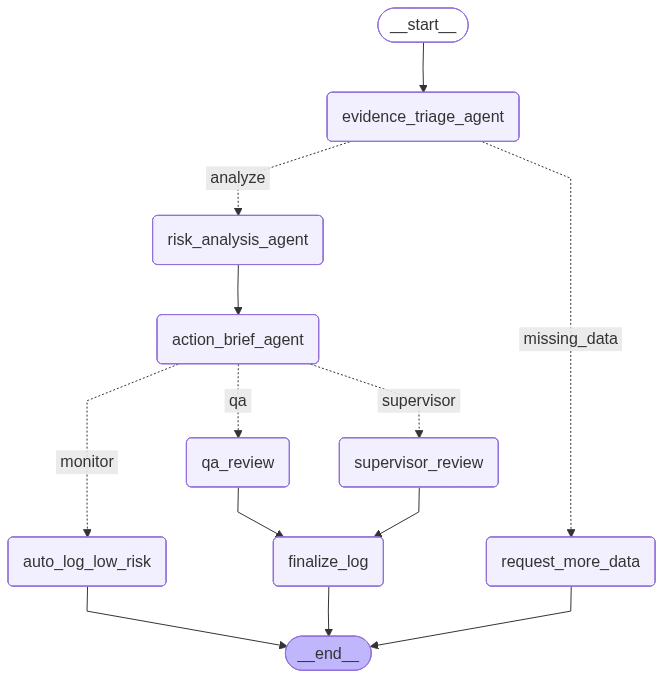

In [ ]:
from IPython.display import Image

Image(food_safety_app.get_graph().draw_mermaid_png(max_retries=10))

## Demo 1: Low-risk case goes to MONITOR

This case includes reassuring plant-floor notes, not only clean numbers. The agents should interpret the notes and route to `auto_log_low_risk` without human review.

In [ ]:
low_risk_case = {
    "case_id": "FS-2026-001",
    "product": "Cooked ready-to-eat chicken",
    "batch_id": "BATCH-CH-0519-A",
    "cooling_minutes_to_5c": 104,
    "max_temperature_c": 5.1,
    "lab_result_status": "pass",
    "batch_record_complete": True,
    "sensor_record_complete": True,
    "complaint_count_14d": 1,
    "operator_note": "Cooling cart was loaded 12 minutes later than planned during shift handover. No manual temperature correction was used.",
    "sensor_trend_note": "Continuous logger shows a brief slowdown after one short door-open event, then a steady decrease to the target range. No missing interval or sustained plateau is shown in the file.",
    "qa_note": "QA spot check matched the logger within the allowed tolerance. Label and batch code were verified. QA asked production to monitor the next batch from the same line.",
    "complaint_note": "One texture complaint was received for the same product family last week, but it was from a different production date and is not linked to this batch, route, or lot.",
}

```
จุดสังเกต: LOW Case
# - มีความผิดปกติเล็กน้อย: โหลดเข้า chiller ช้ากว่ากำหนด, มี door-open สั้น ๆ, cooling time ใกล้ขอบ
# - แต่หลักฐานหลักยังครบ: lab pass, batch record ครบ, sensor record ครบ
# - trend ยังควบคุมได้: ไม่มี missing interval หรือ sustained plateau
# - complaint มี 1 เคส แต่ไม่ link กับ batch/route/lot นี้
```

Run the workflow:

In [14]:
config_low = {"configurable": {"thread_id": "food-safety-demo-low"}}

print(f"Case: {low_risk_case['case_id']} | {low_risk_case['batch_id']}")
print("-" * 60)
for event in food_safety_app.stream(low_risk_case, config=config_low, stream_mode="updates"):
    for node, update in event.items():
        print()
        print(f"[{node}]")
        if node == "evidence_triage_agent":
            print("Evidence complete:", update["evidence_complete"])
        elif node == "risk_analysis_agent":
            print("Risk level:", update["risk_level"])
            print("Reasoning:", update["reasoning"])
        elif node == "action_brief_agent":
            print("Recommendation:", update["ai_recommendation"])
            print("Brief:", update["action_brief"])
        elif node == "auto_log_low_risk":
            print("Final status:", update["final_status"])

Case: FS-2026-001 | BATCH-CH-0519-A
------------------------------------------------------------

[evidence_triage_agent]
Evidence complete: True

[risk_analysis_agent]
Risk level: LOW
Reasoning: This case has a low risk level because all required evidence is available, the lab result status is 'pass', and the cooling time to 5°C is within the allowed limit. Although there was a minor delay in loading the cooling cart, it did not affect the temperature, and the QA spot check confirmed the logger's accuracy. Additionally, the texture complaint received last week is not linked to this batch.

[action_brief_agent]
Recommendation: MONITOR
Brief: Monitor the next batch from the same line as per QA's request due to a minor delay in loading the cooling cart during shift handover.

[auto_log_low_risk]
Final status: AUTO_LOGGED_MONITOR_ONLY


## Demo 2: Medium-risk case goes to INVESTIGATE

The structured values are only mildly abnormal, but the notes mention an equipment/shift pattern worth checking. This is where the LLM agent has useful work to do: summarize messy evidence and prepare supervisor questions.

In [ ]:
medium_risk_case = {
    "case_id": "FS-2026-002",
    "product": "Cooked ready-to-eat chicken",
    "batch_id": "BATCH-CH-0519-B",
    "cooling_minutes_to_5c": 116,
    "max_temperature_c": 5.8,
    "lab_result_status": "pass",
    "batch_record_complete": True,
    "sensor_record_complete": True,
    "complaint_count_14d": 1,
    "operator_note": "The second cooling cart was loaded during shift handover. Operator wrote that airflow felt weaker on the upper tray, but no active alarm was recorded.",
    "sensor_trend_note": "Logger shows a short plateau slightly above the target temperature for 18 minutes before returning to the target range. No samples are missing.",
    "qa_note": "QA asks production to check whether the same cart has repeated slow-cooling observations this week.",
    "complaint_note": "One texture complaint was received from a nearby production date, but it is not clearly linked to this batch or route.",
}

```
จุดสังเกต: MEDIUM
# - มี process signal ที่ควร investigate: cooling ใกล้ limit, temp สูงกว่า target, short plateau 18 นาที
# - operator note มี weak airflow แต่ยังไม่มี active alarm
# - หลักฐานยังครบ: lab pass, batch record ครบ, sensor record ครบ # - complaint มี 1 เคส แต่ linkage ยังไม่ชัด
# - QA ขอเช็ค repeated slow-cooling observation จึงเหมาะกับ investigation ไม่ใช่ low monitor เฉย ๆ
```

Run the workflow:

In [ ]:
config_02 = {"configurable": {"thread_id": "food-safety-demo-02"}}
config_medium = {"configurable": {"thread_id": "food-safety-demo-medium"}}

print(f"Case: {medium_risk_case['case_id']} | {medium_risk_case['batch_id']}")
print("-" * 60)
for event in food_safety_app.stream(medium_risk_case, config=config_medium, stream_mode="updates"):
    if "__interrupt__" in event:
        payload = event["__interrupt__"][0].value
        print()
        print("[HUMAN REVIEW REQUIRED]")
        print(payload["message"])
        print("Recommendation:", payload["ai_recommendation"])
        print("Brief:", payload["action_brief"])
        print("Recommended checks:")
        for item in payload.get("recommended_checks", []):
            print("-", item)
        print("Questions:")
        for q in payload["review_questions"]:
            print("-", q)
        continue

    for node, update in event.items():
        print()
        print(f"[{node}]")
        if node == "evidence_triage_agent":
            print("Evidence complete:", update["evidence_complete"])
        elif node == "risk_analysis_agent":
            print("Risk level:", update["risk_level"])
            print("Reasoning:", update["reasoning"])
        elif node == "action_brief_agent":
            print("Recommendation:", update["ai_recommendation"])
            print("Review role:", update["review_role"])
            print("Brief:", update["action_brief"])

Case: FS-2026-002-MED | BATCH-CH-0519-M
------------------------------------------------------------

[evidence_triage_agent]
Evidence complete: True

[risk_analysis_agent]
Risk level: MEDIUM
Reasoning: This case has a MEDIUM risk level due to non-critical abnormal signals, including a slightly longer cooling time and a higher maximum temperature than target. Additionally, there is a customer complaint, but it's not clearly linked to this batch or route. QA has also raised a concern about potential slow-cooling observations on the same cart, which warrants further investigation.

[action_brief_agent]
Recommendation: INVESTIGATE
Review role: SUPERVISOR_OR_PROCESS_OWNER
Brief: Investigate potential slow-cooling observations on the same cart used for this batch, as QA has raised a concern. Verify that the cooling process was properly executed and that the cart has not been used for other batches with similar issues.

[HUMAN REVIEW REQUIRED]
Supervisor/process owner review required for INV

## Resume after supervisor/process owner review

The supervisor or process owner now decides what to do with the investigation case.

In [ ]:
supervisor_decision = {
    "decision": "CONTINUE_INVESTIGATION",
    "comment": "Check line cooling trend and shift notes before deciding whether QA escalation is needed.",
}

print("Resume with supervisor decision")
print("-" * 60)
for event in food_safety_app.stream(Command(resume=supervisor_decision), config=config_medium, stream_mode="updates"):
    for node, update in event.items():
        print()
        print(f"[{node}]")
        if node == "supervisor_review":
            print("Human decision:", update["human_decision"])
            print("Comment:", update["human_comment"])
        elif node == "finalize_log":
            print("Final status:", update["final_status"])

Resume with supervisor decision
------------------------------------------------------------

[supervisor_review]
Human decision: CONTINUE_INVESTIGATION
Comment: Check line cooling trend and shift notes before deciding whether QA escalation is needed.

[finalize_log]
Final status: HUMAN_REVIEW_DECISION_LOGGED


## Demo 3: High-risk case pauses for QA/Food Safety review

This case has high-risk structured values and concerning notes. The agents should create a QA/Food Safety brief rather than just applying a threshold.

In [ ]:
high_risk_case = {
    "case_id": "FS-2026-003",
    "product": "Cooked ready-to-eat chicken",
    "batch_id": "BATCH-CH-0519-C",
    "cooling_minutes_to_5c": 145,
    "max_temperature_c": 9.2,
    "lab_result_status": "pass",
    "batch_record_complete": True,
    "sensor_record_complete": True,
    "complaint_count_14d": 1,
    "operator_note": "The blast chiller door was opened several times while maintenance checked fan noise. Operator wrote that the batch stayed on the cart longer than usual before transfer.",
    "sensor_trend_note": "Logger shows the product stayed above the target temperature for an extended period. The cooling curve flattened during the maintenance window.",
    "qa_note": "QA requested review of the cooling profile and asked for maintenance timing to be compared with the logger record.",
    "complaint_note": "One complaint mentions warm product on receipt from the same route family, but batch linkage is not confirmed.",
}

```
จุดสังเกต: HIGH
# - มี clear process deviation: cooling time เกินมาก, max temp สูง, door opened several times
# - มี maintenance ระหว่าง cooling และ product stayed on cart longer than usual
# - sensor trend บอกว่าอยู่เหนือ target temperature เป็น extended period
# - มี possible customer impact: warm product complaint จาก same route family # - แม้ lab pass และ record ครบ แต่ risk signal จาก process/temperature ชัดเจน
```

Run the workflow:

In [ ]:
config_high = {"configurable": {"thread_id": "food-safety-demo-high"}}

print(f"Case: {high_risk_case['case_id']} | {high_risk_case['batch_id']}")
print("-" * 60)
for event in food_safety_app.stream(high_risk_case, config=config_high, stream_mode="updates"):
    if "__interrupt__" in event:
        payload = event["__interrupt__"][0].value
        print()
        print("[HUMAN REVIEW REQUIRED]")
        print(payload["message"])
        print("Recommendation:", payload["ai_recommendation"])
        print("Brief:", payload["action_brief"])
        print("Recommended checks:")
        for item in payload.get("recommended_checks", []):
            print("-", item)
        print("Questions:")
        for q in payload["review_questions"]:
            print("-", q)
        continue

    for node, update in event.items():
        print()
        print(f"[{node}]")
        if node == "evidence_triage_agent":
            print("Evidence complete:", update["evidence_complete"])
        elif node == "risk_analysis_agent":
            print("Risk level:", update["risk_level"])
            print("Reasoning:", update["reasoning"])
        elif node == "action_brief_agent":
            print("Recommendation:", update["ai_recommendation"])
            print("Review role:", update["review_role"])
            print("Brief:", update["action_brief"])

Case: FS-2026-003-HIGH | BATCH-CH-0519-H
------------------------------------------------------------

[evidence_triage_agent]
Evidence complete: True

[risk_analysis_agent]
Risk level: HIGH
Reasoning: This case is classified as HIGH risk due to the prolonged cooling time, excessive maximum temperature, and potential impact on product safety. Additionally, the blast chiller door was opened multiple times during maintenance, and the batch was delayed before transfer, which may have compromised the cooling process. Furthermore, a complaint was received regarding warm product, although lot linkage is not confirmed.

[action_brief_agent]
Recommendation: HOLD_FOR_QA_REVIEW
Review role: QA_OR_FOOD_SAFETY
Brief: Hold the batch for QA review due to potential impact on product safety. Verify the cooling process was not compromised by the blast chiller door being opened multiple times during maintenance and the batch being delayed before transfer.

[HUMAN REVIEW REQUIRED]
QA/Food Safety approval

## Resume after QA/Food Safety review

QA/Food Safety now makes the decision. This is the human-in-the-loop step for high-risk cases.

In [ ]:
qa_decision = {
    "decision": "HOLD_FOR_QA_REVIEW",
    "comment": "Hold this batch until QA verifies cooling records and completes deviation assessment.",
}

print("Resume with QA/Food Safety decision")
print("-" * 60)
for event in food_safety_app.stream(Command(resume=qa_decision), config=config_high, stream_mode="updates"):
    for node, update in event.items():
        print()
        print(f"[{node}]")
        if node == "qa_review":
            print("Human decision:", update["human_decision"])
            print("Comment:", update["human_comment"])
        elif node == "finalize_log":
            print("Final status:", update["final_status"])

Resume with QA/Food Safety decision
------------------------------------------------------------

[qa_review]
Human decision: HOLD_FOR_QA_REVIEW
Comment: Hold this batch until QA verifies cooling records and completes deviation assessment.

[finalize_log]
Final status: HUMAN_REVIEW_DECISION_LOGGED


## Demo 4: Missing or weak evidence stops before risk/action agents

This case has a missing sensor record plus notes that say the available data is incomplete. Evidence Triage Agent should request data rather than letting the risk/action agents continue.

In [ ]:
missing_evidence_case = {
    "case_id": "FS-2026-004",
    "product": "Fresh-cut fruit cup",
    "batch_id": "BATCH-FR-0519-A",
    "cooling_minutes_to_5c": 130,
    "max_temperature_c": 6.5,
    "lab_result_status": "pass",
    "batch_record_complete": True,
    "sensor_record_complete": False,
    "complaint_count_14d": 0,
    "operator_note": "Batch record is present. Operator wrote that a handheld reading was used after the fixed logger stopped recording.",
    "sensor_trend_note": "Fixed logger file is not available after 10:40. Temperature history during transfer cannot be reconstructed from the uploaded file.",
    "qa_note": "QA asks for the raw logger export or maintenance confirmation before risk classification.",
    "complaint_note": "No complaint is currently linked to this batch or production date.",
}

config_missing = {"configurable": {"thread_id": "food-safety-demo-missing"}}

print(f"Case: {missing_evidence_case['case_id']} | {missing_evidence_case['batch_id']}")
print("-" * 60)
for event in food_safety_app.stream(missing_evidence_case, config=config_missing, stream_mode="updates"):
    for node, update in event.items():
        print()
        print(f"[{node}]")
        if node == "evidence_triage_agent":
            print("Evidence complete:", update["evidence_complete"])
            print("Missing/weak evidence:", ", ".join(update["missing_evidence"]))
            print("Data request:", update["data_request_message"])
        elif node == "request_more_data":
            print("Final status:", update["final_status"])

Case: FS-2026-004-MISSING | BATCH-FR-0519-B
------------------------------------------------------------

[evidence_triage_agent]
Evidence complete: False
Missing/weak evidence: sensor_record_complete, sensor_record
Data request: Please provide the complete sensor record for batch BATCH-FR-0519-B.

[request_more_data]
Final status: WAITING_FOR_MORE_EVIDENCE
